In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("IRIS.csv")

In [3]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.isnull().sum()


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
df=df.drop_duplicates()

In [7]:
# to detect outlaiers

numeric_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

# Remove extreme values using the IQR method
for column in numeric_columns:

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df = df[(df[column] >= lower) & (df[column] <= upper)]

In [8]:
X= df.drop("species",axis=1)
y= df["species"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [10]:
model = StandardScaler()

X_train = model.fit_transform(X_train)
X_test = model.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
predictions = model.predict(X_test)

In [12]:
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.9310344827586207


In [13]:
print(classification_report(y_test, predictions))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        29
      macro avg       0.93      0.93      0.93        29
   weighted avg       0.93      0.93      0.93        29



In [14]:
print(confusion_matrix(y_test, predictions))

[[9 0 0]
 [0 9 1]
 [0 1 9]]


In [15]:
# testing is model overfitted or not 

# Training accuracy
train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

# Testing accuracy
test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Training Accuracy : {train_accuracy:.2%}")
print(f"Testing Accuracy  : {test_accuracy:.2%}")

difference = train_accuracy - test_accuracy
print(f"Difference        : {difference:.2%}")

Training Accuracy : 96.49%
Testing Accuracy  : 93.10%
Difference        : 3.39%


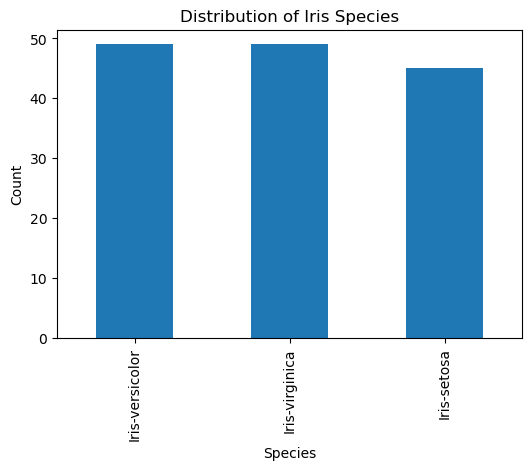

In [16]:
plt.figure(figsize=(6,4))

df["species"].value_counts().plot(kind="bar")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

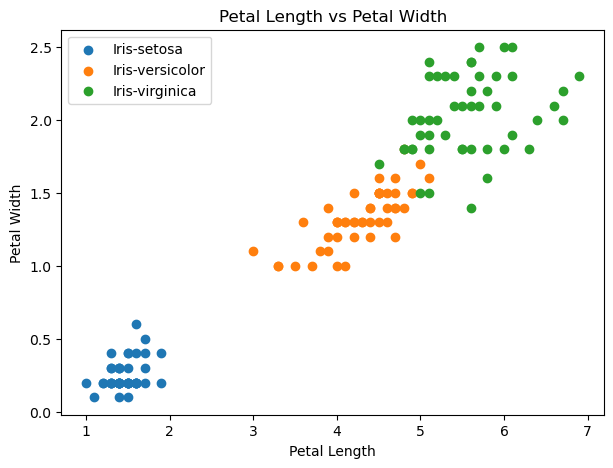

In [18]:
plt.figure(figsize=(7,5))

for flower in df["species"].unique():

    temp = df[df["species"] == flower]

    plt.scatter(
        temp["petal_length"],
        temp["petal_width"],
        label=flower
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width")

plt.legend()

plt.show()